# F1 Race Analytics — 04: Final Visualizations
**Purpose:** Polished, presentation-ready charts for the README and as a visual reference for the Power BI dashboard.  
**Output:** PNG files saved to `assets/` for direct use in documentation.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../assets', exist_ok=True)

df          = pd.read_csv('../data/processed/race_results_clean.csv')
driver_season = pd.read_csv('../data/processed/driver_season_stats.csv')
pole_conv   = pd.read_csv('../data/processed/pole_conversion.csv')
pit_summary = pd.read_csv('../data/processed/pit_stop_summary.csv')
df_const    = pd.read_csv('../data/raw/constructor_standings.csv')

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.titlepad': 14
})

F1_RED = '#E10600'
F1_NAVY = '#15151E'
F1_GRAY = '#949498'

print('Data loaded. Ready to build final visuals.')

Data loaded. Ready to build final visuals.


## Chart 1 — Championship Dominance: Points Gap (1st vs 2nd)

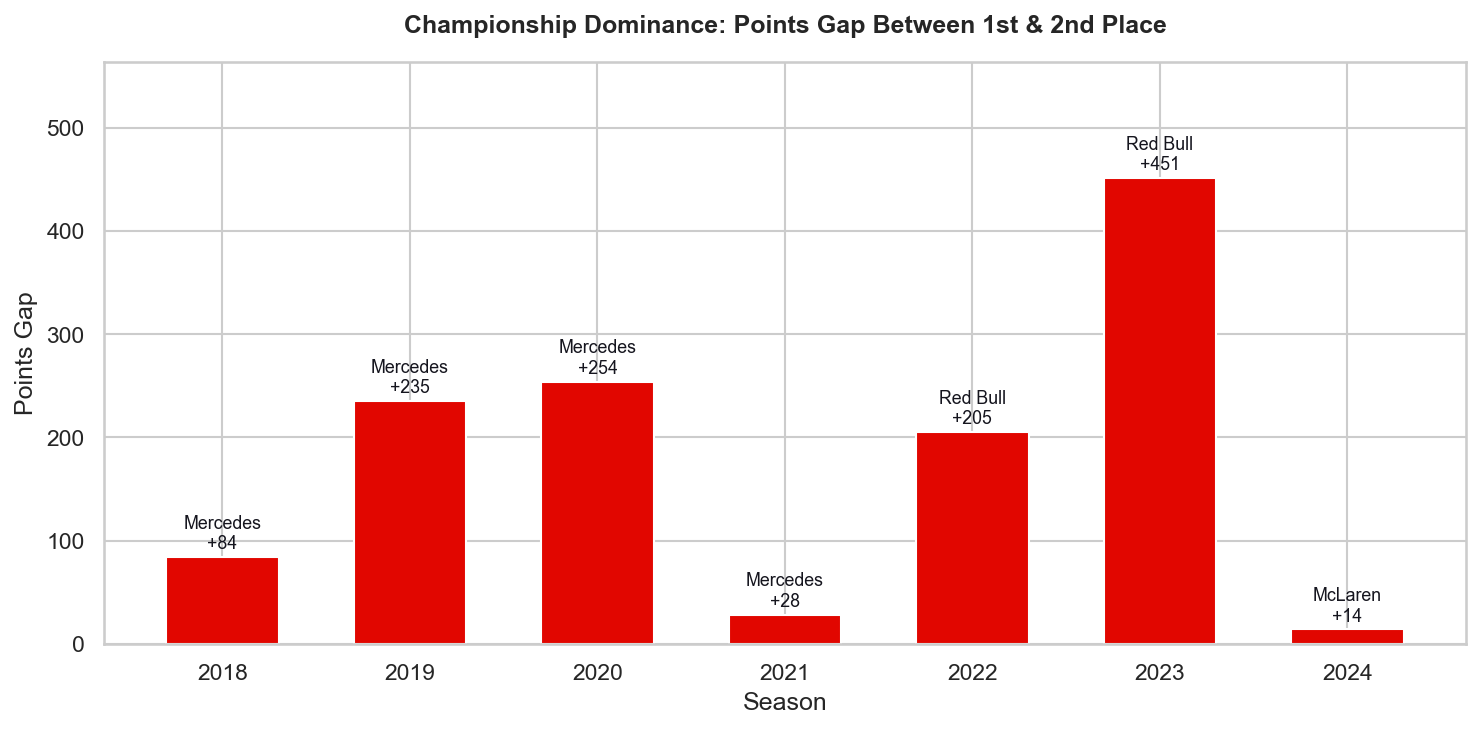

In [2]:
champ_gap = []
for season in sorted(df_const['season'].unique()):
    season_df = df_const[df_const['season'] == season].sort_values('points', ascending=False)
    if len(season_df) < 2:
        continue
    champ = season_df.iloc[0]
    runner_up = season_df.iloc[1]
    champ_gap.append({
        'season': season,
        'champion': champ['constructor'],
        'gap': champ['points'] - runner_up['points']
    })
champ_gap_df = pd.DataFrame(champ_gap)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(champ_gap_df['season'].astype(str), champ_gap_df['gap'], color=F1_RED, edgecolor='white', width=0.6)
for bar, row in zip(bars, champ_gap_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, f"{row.champion}\n+{row.gap:.0f}",
            ha='center', fontsize=8.5, color=F1_NAVY)
ax.set_title('Championship Dominance: Points Gap Between 1st & 2nd Place')
ax.set_xlabel('Season'); ax.set_ylabel('Points Gap')
ax.set_ylim(0, champ_gap_df['gap'].max() * 1.25)
plt.tight_layout()
plt.savefig('../assets/05_championship_dominance.png', bbox_inches='tight')
plt.show()

## Chart 2 — Driver Reliability vs Performance (Scatter)

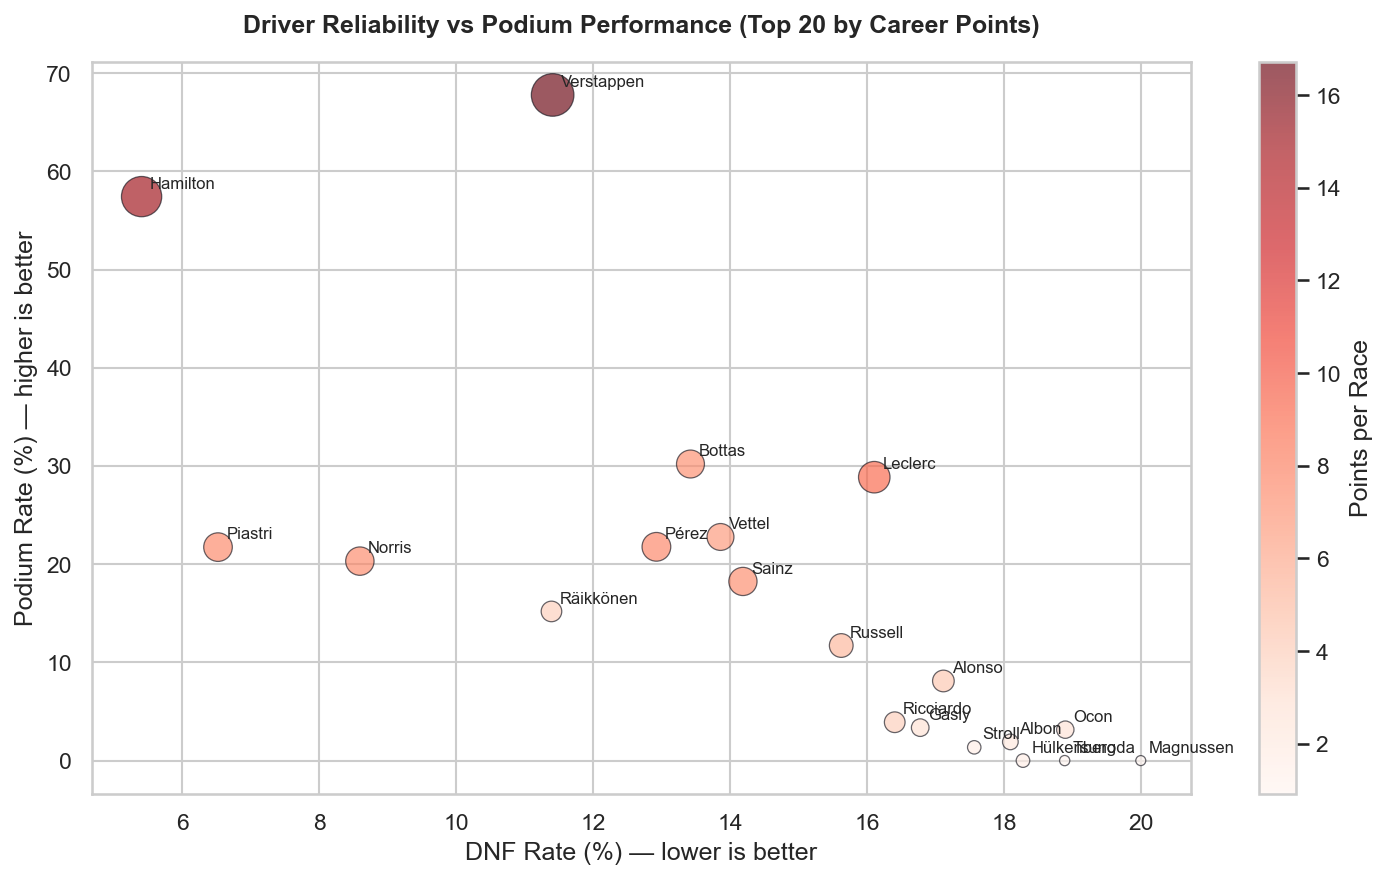

In [3]:
career = driver_season.groupby('driver_name').agg(
    total_races=('races','sum'),
    total_points=('total_points','sum'),
    total_podiums=('podiums','sum'),
    total_dnfs=('dnfs','sum')
).reset_index()
career = career[career['total_races'] >= 20]
career['podium_rate'] = career['total_podiums'] / career['total_races'] * 100
career['dnf_rate'] = career['total_dnfs'] / career['total_races'] * 100
career['points_per_race'] = career['total_points'] / career['total_races']

top20 = career.nlargest(20, 'total_points')

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(top20['dnf_rate'], top20['podium_rate'],
                      s=top20['points_per_race'] * 25, alpha=0.65,
                      c=top20['points_per_race'], cmap='Reds', edgecolors=F1_NAVY, linewidth=0.6)

for _, row in top20.iterrows():
    last_name = row['driver_name'].split()[-1]
    ax.annotate(last_name, (row['dnf_rate'], row['podium_rate']),
                fontsize=8, xytext=(4,4), textcoords='offset points')

ax.set_title('Driver Reliability vs Podium Performance (Top 20 by Career Points)')
ax.set_xlabel('DNF Rate (%) — lower is better')
ax.set_ylabel('Podium Rate (%) — higher is better')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Points per Race')
plt.tight_layout()
plt.savefig('../assets/06_driver_reliability_scatter.png', bbox_inches='tight')
plt.show()

## Chart 3 — Pit Stop Speed Distribution by Top Constructors

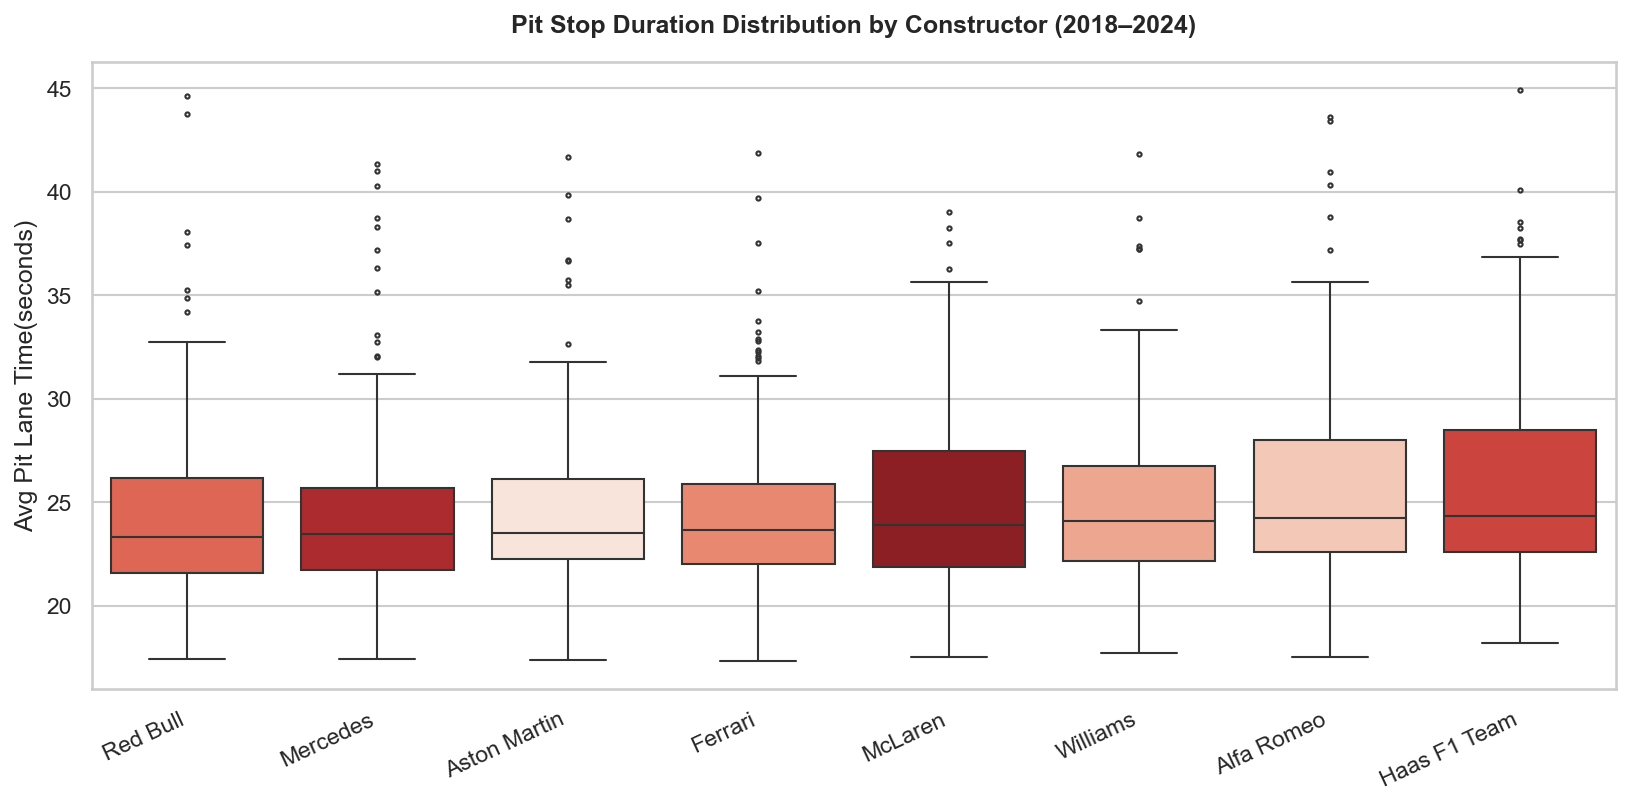

In [8]:
pit_with_constructor = pd.merge(
    pit_summary,
    df[['season','round','driver_id','constructor']].drop_duplicates(),
    on=['season','round','driver_id'],
    how='left'
)
pit_clean = pit_with_constructor[
    (pit_with_constructor['avg_stop_duration'] > 15) &
    (pit_with_constructor['avg_stop_duration'] < 45)
]

top_pit_constructors = pit_clean['constructor'].value_counts().nlargest(8).index
pit_plot_df = pit_clean[pit_clean['constructor'].isin(top_pit_constructors)]

fig, ax = plt.subplots(figsize=(11, 5.5))
order = pit_plot_df.groupby('constructor')['avg_stop_duration'].median().sort_values().index
sns.boxplot(data=pit_plot_df, x='constructor', y='avg_stop_duration', order=order,
            hue='constructor', palette='Reds_r', legend=False, ax=ax, fliersize=2)
ax.set_title('Pit Stop Duration Distribution by Constructor (2018–2024)')
ax.set_xlabel(''); ax.set_ylabel('Avg Pit Lane Time(seconds)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../assets/07_pitstop_distribution.png', bbox_inches='tight')
plt.show()

## Chart 4 — Season Win Share Heatmap (Constructor x Season)

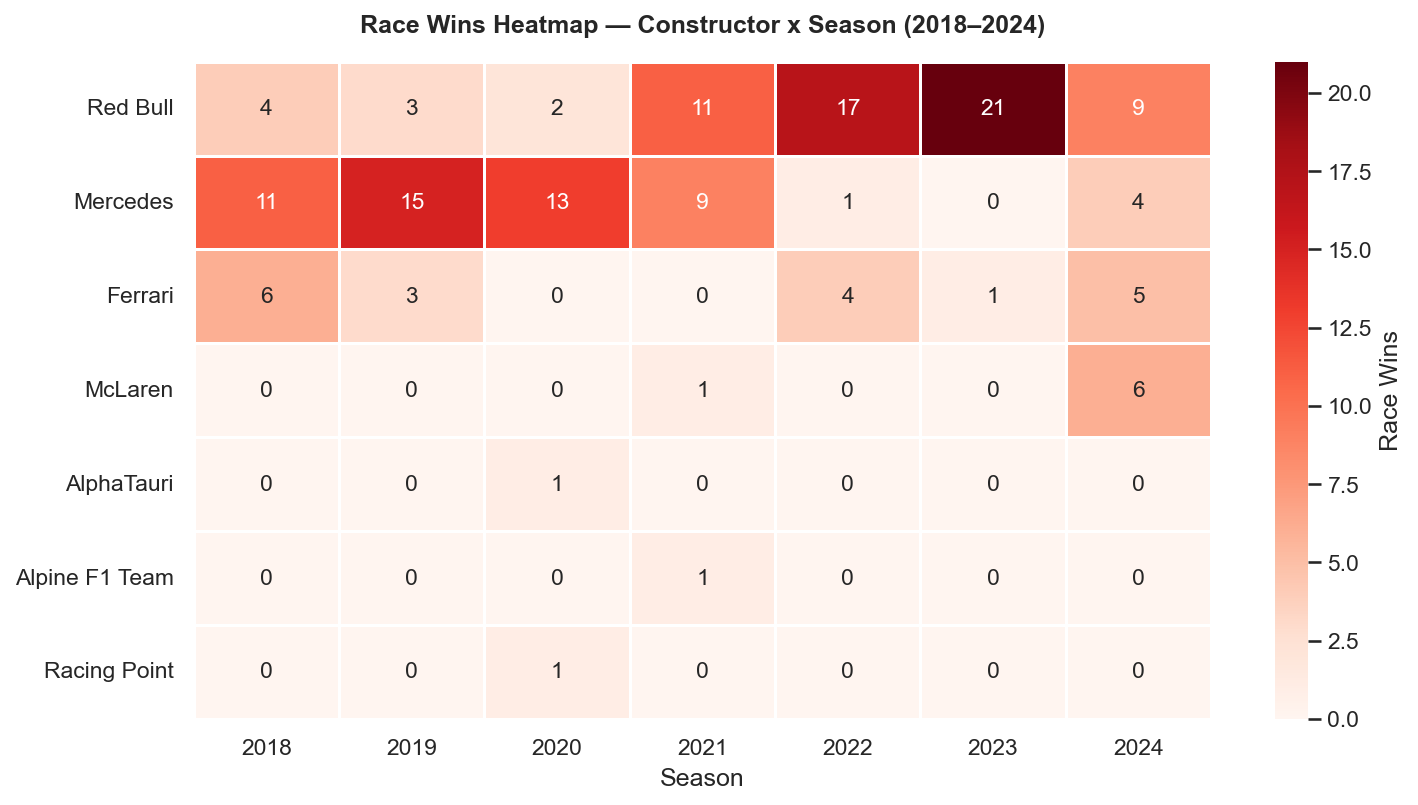

In [9]:
wins = df[df['win_flag'] == True].groupby(['season','constructor']).size().reset_index(name='wins')
top_constructors_all = df[df['win_flag']].groupby('constructor').size().nlargest(8).index
wins_top = wins[wins['constructor'].isin(top_constructors_all)]
heatmap_data = wins_top.pivot(index='constructor', columns='season', values='wins').fillna(0)
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Race Wins'}, ax=ax)
ax.set_title('Race Wins Heatmap — Constructor x Season (2018–2024)')
ax.set_xlabel('Season'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../assets/08_wins_heatmap.png', bbox_inches='tight')
plt.show()

## Summary — All Charts Saved

In [10]:
import glob
saved = sorted(glob.glob('../assets/*.png'))
print(f'{len(saved)} charts saved to assets/:')
for f in saved:
    print(f'  - {os.path.basename(f)}')

8 charts saved to assets/:
  - 01_constructor_wins.png
  - 02_pole_conversion.png
  - 03_driver_consistency.png
  - 04_position_delta.png
  - 05_championship_dominance.png
  - 06_driver_reliability_scatter.png
  - 07_pitstop_distribution.png
  - 08_wins_heatmap.png
